In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)
sns.set_theme(style="darkgrid")

print("import done!")

import done!


In [6]:
train_df = pd.read_csv('../data/twitter_training.csv', header=None)
val_df = pd.read_csv('../data/twitter_validation.csv', header=None)

train_df.columns = ['id','entity','sentiment','text']
val_df.columns = ['id', 'entity', 'sentiment', 'text']

print("Train shape :", train_df.shape)
print("Val shape :", val_df.shape)

Train shape : (74682, 4)
Val shape : (1000, 4)


In [7]:
print("== TRAIN DATA INFO ==")
print(train_df.info())
print("\n=== MISSING VALUES ===")
print(train_df.isnull().sum())
print("\n=== SENTIMENT CLASSES ===")
print(train_df['sentiment'].value_counts())

== TRAIN DATA INFO ==
<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         74682 non-null  int64
 1   entity     74682 non-null  str  
 2   sentiment  74682 non-null  str  
 3   text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB
None

=== MISSING VALUES ===
id             0
entity         0
sentiment      0
text         686
dtype: int64

=== SENTIMENT CLASSES ===
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


C:\Users\ankit\AppData\Local\Temp\ipykernel_15780\3952695262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_df, x='sentiment',


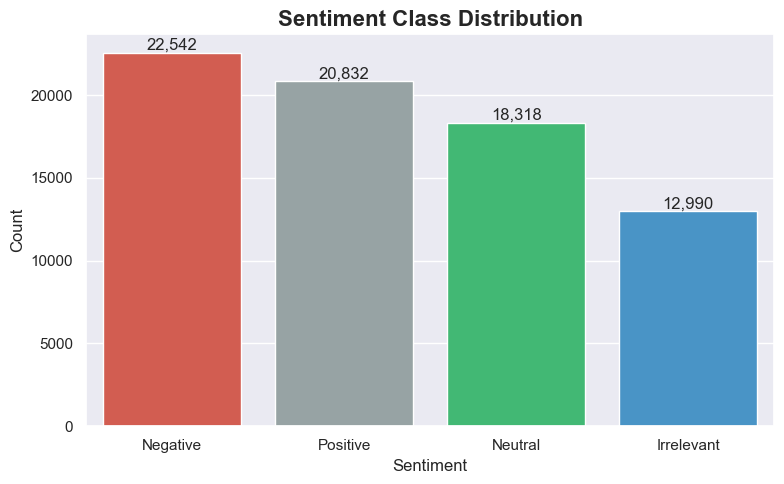

In [8]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='sentiment', 
                   palette=['#e74c3c','#95a5a6','#2ecc71','#3498db'],
                   order=train_df['sentiment'].value_counts().index)

plt.title('Sentiment Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

In [9]:
print(f"Before cleaning : {train_df.shape}")

train_df = train_df.dropna(subset=['text'])
val_df = val_df.dropna(subset=['text'])

train_df = train_df.drop_duplicates(subset=['text'])

print(f"After cleaning: {train_df.shape}")
print(f"rows removed: {74682 - train_df.shape[0]}")

Before cleaning : (74682, 4)
After cleaning: (69491, 4)
rows removed: 5191


In [10]:
import re
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    tokens = text.split()

    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return ' '.join(tokens)

train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text'] = val_df['text'].apply(clean_text)

print("Text cleaning done")

train_df[['text','clean_text']].head(3)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ankit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Text cleaning done


,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill


In [11]:
sample_idx = 0
print("Original Text:", train_df['text'].iloc[sample_idx])
print("cleaned Text:", train_df['clean_text'].iloc[sample_idx])

empty = (train_df['clean_text'].str.strip() == '').sum()
print(f"\nEmpty texts after cleaning: {empty}")

train_df = train_df[train_df['clean_text'].str.strip() != '']
print(f"Final train size: {train_df.shape}")

Original Text: im getting on borderlands and i will murder you all ,
cleaned Text: im getting borderland murder

Empty texts after cleaning: 383
Final train size: (69108, 5)


Word Count Distribution


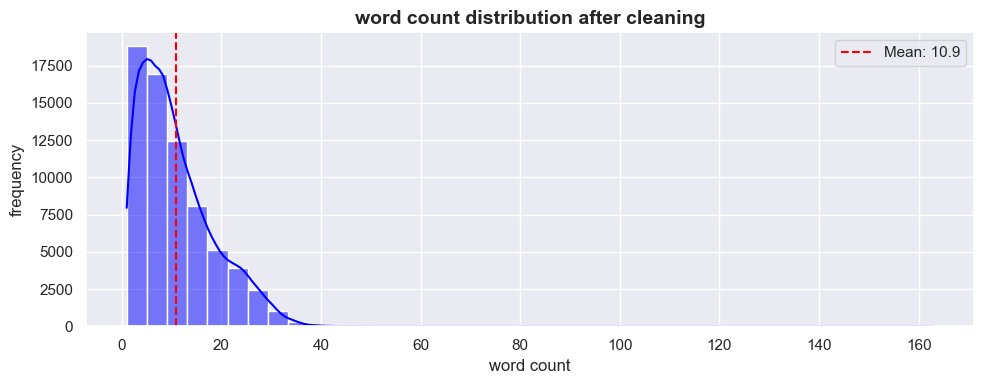

In [12]:
train_df['word_count'] = train_df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,4))
sns.histplot(train_df['word_count'], bins=40, color='blue', kde=True)
plt.title('word count distribution after cleaning', fontsize=14, fontweight='bold')
plt.xlabel('word count')
plt.ylabel('frequency')
plt.axvline(train_df['word_count'].mean(), color='red',
linestyle='--', label=f"Mean: {train_df['word_count'].mean():.1f}")

plt.legend()
plt.tight_layout()
plt.show()

Final class distribution After Cleaning


C:\Users\ankit\AppData\Local\Temp\ipykernel_15780\3087996007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_df, x='sentiment',


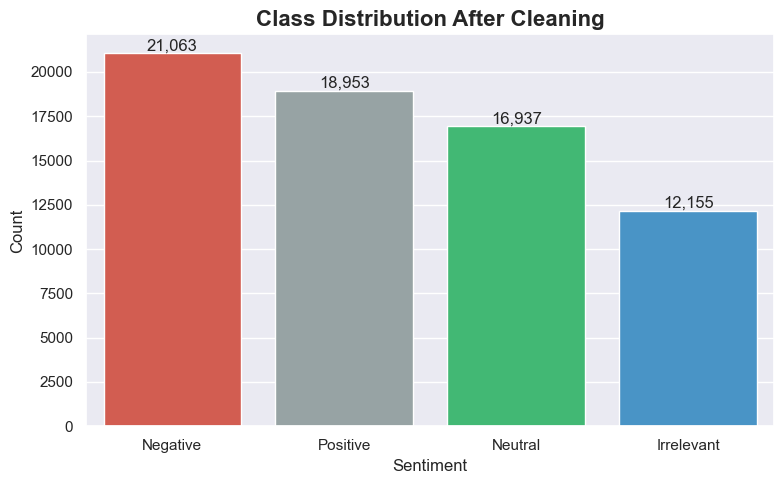


Class counts:
sentiment
Negative      21063
Positive      18953
Neutral       16937
Irrelevant    12155
Name: count, dtype: int64

Imbalance ratio (max/min): 1.73x


In [13]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='sentiment',
                   palette=['#e74c3c','#95a5a6','#2ecc71','#3498db'],
                   order=train_df['sentiment'].value_counts().index)

plt.title('Class Distribution After Cleaning', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

# Print imbalance ratio
counts = train_df['sentiment'].value_counts()
print("\nClass counts:")
print(counts)
print(f"\nImbalance ratio (max/min): {counts.max()/counts.min():.2f}x")

Encode Labels+TF-IDF Vectorization

In [14]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

le = LabelEncoder()
y_train = le.fit_transform(train_df['sentiment'])
y_val = le.transform(val_df['sentiment'])


print("Classrs:", le.classes_)
print("encoded:", np.unique(y_train))

vectorizer = TfidfVectorizer(
    max_features = 10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_val = vectorizer.transform(val_df['clean_text'])

print(f"\nX_train shape:  {X_train.shape}   y_train shape: {y_train.shape}  ")
print(f"\nVocabulary size: {len(vectorizer.vocabulary_):,}")

Classrs: ['Irrelevant' 'Negative' 'Neutral' 'Positive']
encoded: [0 1 2 3]

X_train shape:  (69108, 10000)   y_train shape: (69108,)  

Vocabulary size: 10,000


**APPLY SMOTE**



In [15]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
unique, counts = np.unique(y_train_sm, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt}")

print(f"\nNew training size: {X_train_sm.shape[0]:,}")

Before SMOTE:
  Irrelevant: 12155
  Negative: 21063
  Neutral: 16937
  Positive: 18953

After SMOTE:
  Irrelevant: 21063
  Negative: 21063
  Neutral: 21063
  Positive: 21063

New training size: 84,252


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import time

print("⏳ Training model...")
start = time.time()

model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42
    # multi_class removed — newer sklearn handles it automatically ✅
)

model.fit(X_train_sm, y_train_sm)

end = time.time()
print(f"✅ Training done in {end-start:.1f} seconds!")

⏳ Training model...
✅ Training done in 4.7 seconds!



**Evaluate**


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Irrelevant       0.74      0.90      0.81       172
    Negative       0.86      0.88      0.87       266
     Neutral       0.91      0.79      0.85       285
    Positive       0.87      0.87      0.87       277

    accuracy                           0.85      1000
   macro avg       0.85      0.86      0.85      1000
weighted avg       0.86      0.85      0.85      1000



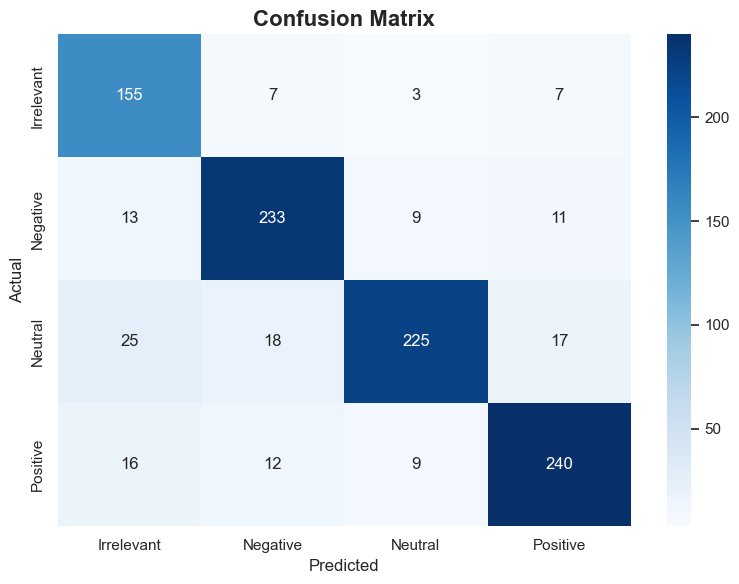

In [20]:
# Predictions
y_pred = model.predict(X_val)

# Classification Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_pred, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [21]:
import joblib
import os

os.makedirs('../model', exist_ok = True)


joblib.dump(model, '../model/model.pkl')
joblib.dump(vectorizer, '../model/vectorizer.pkl')
joblib.dump(le, '../model/label_encoder.pkl')


print("Saved:")
print("   ../model/model.pkl ")
print("   ../model/vectorizer.pkl")
print("   ../model/label_encoder.pkl") 


for f in ['model.pkl', 'vectorizer.pkl', 'label_encoder.pkl']:
    path = os.path.join('../model', f)
    size = os.path.getsize(path) / 1024
    print(f"  {f}: {size:.1f} KB")

Saved:
   ../model/model.pkl 
   ../model/vectorizer.pkl
   ../model/label_encoder.pkl
  model.pkl: 313.4 KB
  vectorizer.pkl: 373.2 KB
  label_encoder.pkl: 0.5 KB


In [22]:
# Test prediction pipeline end to end
def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    label = le.inverse_transform([prediction])[0]
    confidence = round(float(probability.max()), 4)
    
    return {
        "text": text,
        "sentiment": label,
        "confidence": confidence
    }

# Test with 3 examples
tests = [
    "I absolutely love this product, it's amazing!",
    "This is the worst experience I've ever had",
    "The weather today is cloudy"
]

for t in tests:
    result = predict_sentiment(t)
    print(f"Text      : {result['text']}")
    print(f"Sentiment : {result['sentiment']}")
    print(f"Confidence: {result['confidence']}")
    print("-" * 50)

Text      : I absolutely love this product, it's amazing!
Sentiment : Positive
Confidence: 0.6565
--------------------------------------------------
Text      : This is the worst experience I've ever had
Sentiment : Negative
Confidence: 0.5062
--------------------------------------------------
Text      : The weather today is cloudy
Sentiment : Positive
Confidence: 0.5262
--------------------------------------------------


In [23]:
import shap 

background_size = 500
np.random.seed(42)
background_idx = np.random.choice(X_train_sm.shape[0],
background_size,
replace=False)
X_background = X_train_sm[background_idx]


print("Creating SHAP explainer....")
explainer = shap.LinearExplainer(model, X_background)

print("SHAP explianer ready!!")



d:\Projects\sentiment-analyzer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Creating SHAP explainer....
SHAP explianer ready!!


explain a single prediction

In [29]:
def explain_prediction(text, top_n=10):
    cleaned = clean_text(text)
    X = vectorizer.transform([cleaned])
    
    shap_values = explainer.shap_values(X)
    
    pred_class_idx = model.predict(X)[0]
    pred_label = le.inverse_transform([pred_class_idx])[0]
    confidence = model.predict_proba(X)[0].max()
    
    feature_names = vectorizer.get_feature_names_out()
    
    # DEBUG
    print(f"shap_values type  : {type(shap_values)}")
    if isinstance(shap_values, list):
        print(f"shap_values length: {len(shap_values)}")
        print(f"shap_values[0] shape: {shap_values[0].shape}")
    else:
        print(f"shap_values shape: {shap_values.shape}")
    print(f"pred_class_idx: {pred_class_idx}")
    
    # Handle both formats
    if isinstance(shap_values, list):
        sv = shap_values[pred_class_idx][0]
    else:
        if shap_values.ndim == 3:
            sv = shap_values[0, :, pred_class_idx]
        else:
            sv = shap_values[0]
    
    top_idx = np.argsort(np.abs(sv))[::-1][:top_n]
    
    print(f"\nText       : {text}")
    print(f"Prediction : {pred_label} ({confidence:.1%} confidence)")
    print(f"\nTop words driving this prediction:")
    print(f"{'Word':<20} {'SHAP Value':>12} {'Direction':>12}")
    print("-" * 46)
    
    for idx in top_idx:
        word = feature_names[idx]
        value = sv[idx]
        direction = "PUSHES UP" if value > 0 else "PUSHES DOWN"
        print(f"{word:<20} {value:>12.4f} {direction:>12}")
    
    return shap_values, pred_class_idx

# Test it!
shap_values, cls_idx = explain_prediction(
    "I absolutely love this product, it's amazing!"
)

shap_values type  : <class 'numpy.ndarray'>
shap_values shape: (1, 10000, 4)
pred_class_idx: 3

Text       : I absolutely love this product, it's amazing!
Prediction : Positive (65.6% confidence)

Top words driving this prediction:
Word                   SHAP Value    Direction
----------------------------------------------
love                       1.0302    PUSHES UP
amazing                    0.9370    PUSHES UP
absolutely love           -0.2370  PUSHES DOWN
absolutely                 0.1460    PUSHES UP
product                   -0.1044  PUSHES DOWN
best                      -0.0363  PUSHES DOWN
player                     0.0238    PUSHES UP
johnson                   -0.0238  PUSHES DOWN
perfect                   -0.0218  PUSHES DOWN
borderland                -0.0215  PUSHES DOWN


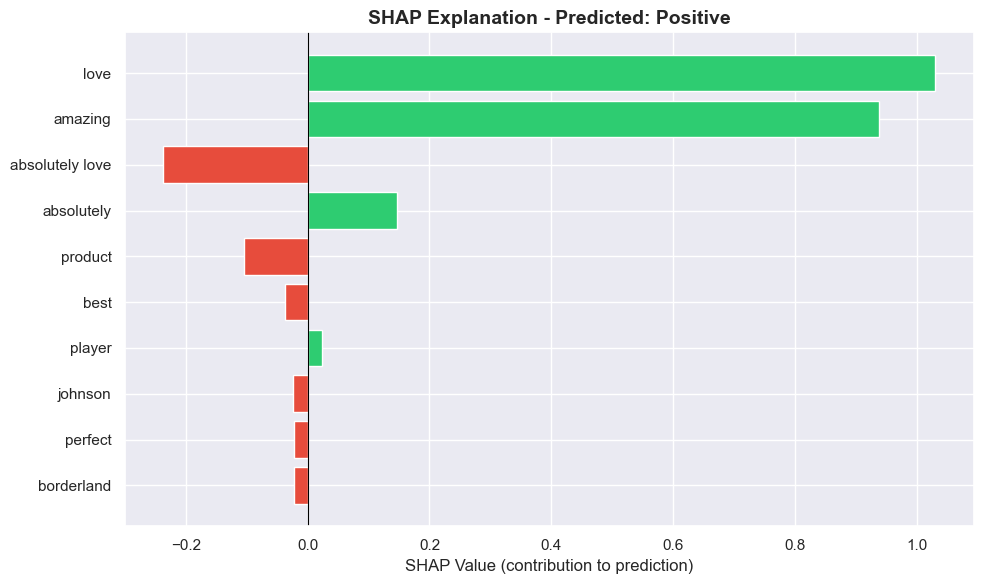

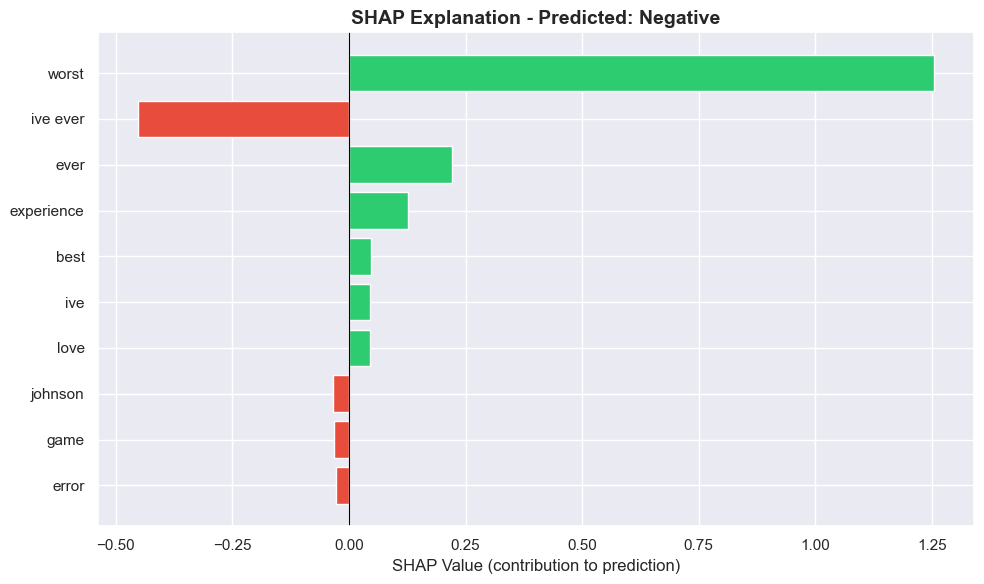

In [31]:
def plot_shap(text, top_n=10):
    cleaned = clean_text(text)
    X = vectorizer.transform([cleaned])
    
    shap_values = explainer.shap_values(X)
    pred_class_idx = model.predict(X)[0]
    pred_label = le.inverse_transform([pred_class_idx])[0]
    
    feature_names = vectorizer.get_feature_names_out()
    
    # Handle both formats — same fix as explain_prediction
    if isinstance(shap_values, list):
        sv = shap_values[pred_class_idx][0]
    else:
        if shap_values.ndim == 3:
            sv = shap_values[0, :, pred_class_idx]
        else:
            sv = shap_values[0]
    
    # Top N words by absolute SHAP value
    top_idx = np.argsort(np.abs(sv))[::-1][:top_n]
    top_words  = [feature_names[i] for i in top_idx]
    top_values = [sv[i] for i in top_idx]
    
    # Green = pushes toward prediction, Red = pushes away
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_values]
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_words[::-1], top_values[::-1], color=colors[::-1])
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title(f'SHAP Explanation - Predicted: {pred_label}',
              fontsize=14, fontweight='bold')
    plt.xlabel('SHAP Value (contribution to prediction)')
    plt.tight_layout()
    plt.show()

# Plot both examples
plot_shap("I absolutely love this product, it's amazing!")
plot_shap("This is the worst experience I've ever had")